# HMM Model Recovery Project

## Recovering a Gaussian Hidden Markov Model From Synthetic Samples

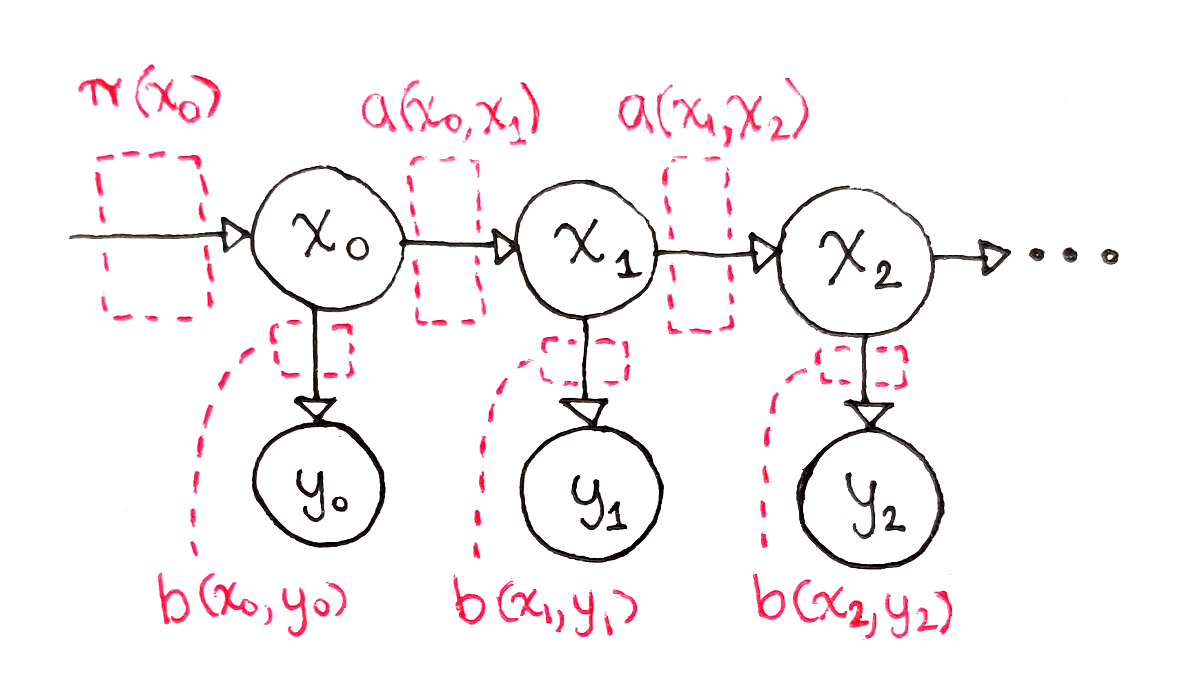

### Afeka College of Engineering  

**Students:**
- אביעד צפרי – 322281452  
- דוד אזימוב – 205697592  

**Course:**
Advanced Method in ML

**Date:**
Semester B, 2026

---


# Table of Contents

1. [Abstract](#1-abstract)
2. [Introduction](#2-introduction)

   1. [Motivation](#21-motivation)
   2. [Project Goal](#22-project-goal)
   3. [Research Questions](#23-research-questions)
3. [Theoretical Background](#3-theoretical-background)

   1. [Hidden Markov Model Definition](#31-hidden-markov-model-definition)
   2. [Gaussian Hidden Markov Model](#32-gaussian-hidden-markov-model)
   3. [The Three Classical HMM Problems](#33-the-three-classical-hmm-problems)
   4. [Forward Algorithm](#34-forward-algorithm)
   5. [Backward Algorithm](#35-backward-algorithm)
   6. [Posterior Probabilities](#36-posterior-probabilities)
   7. [Baum-Welch / EM Algorithm](#37-baum-welch--em-algorithm)
   8. [Viterbi Algorithm](#38-viterbi-algorithm)
   9. [Hidden-State Permutation Problem](#39-hidden-state-permutation-problem)
   10. [Model Complexity](#310-model-complexity)
4. [Original HMM From GitHub Repository](#4-original-hmm-from-github-repository)

   1. [Repository Description](#41-repository-description)
      1. [Imports and Configurations](#411-imports-and-configurations)
   2. [Original Model Parameters](#42-original-model-parameters)
   3. [Interpretation of Hidden States](#43-interpretation-of-hidden-states)
5. [Synthetic Data Generation](#5-synthetic-data-generation)

   1. [Sampling Procedure](#51-sampling-procedure)
   2. [Generated Dataset](#52-generated-dataset)
   3. [Examples of Generated Sequences](#53-examples-of-generated-sequences)
6. [Training a New HMM](#6-training-a-new-hmm)

   1. [Learned Model Configuration](#61-learned-model-configuration)
   2. [Baum-Welch Training Procedure](#62-baum-welch-training-procedure)
   3. [Convergence Analysis](#63-convergence-analysis)
7. [State Alignment Before Comparison](#7-state-alignment-before-comparison)

   1. [Why Alignment Is Required](#71-why-alignment-is-required)
   2. [Alignment Method](#72-alignment-method)
   3. [Aligned Learned Parameters](#73-aligned-learned-parameters)
8. [Model Comparison Methodology](#8-model-comparison-methodology)

   1. [Parameter-Level Comparison](#81-parameter-level-comparison)
   2. [Likelihood-Based Comparison](#82-likelihood-based-comparison)
   3. [Generated Sequence Statistics Comparison](#83-generated-sequence-statistics-comparison)
   4. [Viterbi Path Comparison](#84-viterbi-path-comparison)
9. [Experiments](#9-experiments)

   1. [Main Experiment](#91-main-experiment)
   2. [Effect of Number of Generated Samples](#92-effect-of-number-of-generated-samples)
   3. [Effect of Sequence Length](#93-effect-of-sequence-length)
   4. [Effect of Random Initialization](#94-effect-of-random-initialization)
   5. [Optional: Different Number of Hidden States](#95-optional-different-number-of-hidden-states)
10. [Results](#10-results)

    1. [Original Model Parameters](#101-original-model-parameters)
    2. [Learned Model Parameters](#102-learned-model-parameters)
    3. [Aligned Learned Model Parameters](#103-aligned-learned-model-parameters)
    4. [Convergence Results](#104-convergence-results)
    5. [Quantitative Comparison](#105-quantitative-comparison)
    6. [Generated Samples Comparison](#106-generated-samples-comparison)
11. [Discussion](#11-discussion)
12. [Limitations](#12-limitations)
13. [Conclusions](#13-conclusions)
14. [Future Work](#14-future-work)
15. [Code and Reproducibility](#15-code-and-reproducibility)
16. [References](#16-references)

---


<a id="1-abstract"></a>

# 1. Abstract

In this project, we study whether a Gaussian Hidden Markov Model can be recovered from synthetic samples generated by another HMM.
We use an existing HMM-based market regime detection project as the source of the original model. After fitting or extracting the original Gaussian HMM, we freeze its parameters and treat it as the reference generative model.

Synthetic sequences are generated from the original model. Then, a new Gaussian HMM is trained using only the generated observations. Finally, we compare the learned model with the original model using parameter similarity, likelihood comparison, generated sequence statistics, and Viterbi decoding.

**TODO:** summarize the main numerical findings after completing the experiments.

---


<a id="2-introduction"></a>

# 2. Introduction

<a id="21-motivation"></a>

## 2.1 Motivation

Hidden Markov Models are probabilistic models used for sequential data where the observed behavior is assumed to be driven by hidden states.
They are useful in domains such as speech recognition, biological sequence analysis, financial time-series modeling, signal processing, and regime detection.

In financial markets, hidden states can represent latent market regimes, such as low-volatility growth periods and high-volatility crash periods.

Market regime detection is a suitable example for Hidden Markov Models because financial time series often behave differently during different periods. For example, the market may be in a stable low-volatility regime for a long time, and then switch to a high-volatility regime during a crisis or rapid decline. These regimes are not directly observed, but they affect the observed data, such as returns and volatility.

This structure fits the HMM assumption: the hidden state represents the current market regime, while the observed values are generated according to the current hidden state. The Markov assumption is also reasonable in this context, because market regimes tend to persist for some time, and the probability of moving to a new regime depends mainly on the current regime.

---


<a id="22-project-goal"></a>

## 2.2 Project Goal

The goal of this project is to test whether a new Gaussian HMM can learn the behavior of an original Gaussian HMM using only samples generated from the original model.

The project pipeline is:

$$
\lambda_{original}
\rightarrow
\text{generate synthetic samples}
\rightarrow
\text{train } \hat{\lambda}
\rightarrow
\text{align states}
\rightarrow
\text{compare models}
$$

where:

$$
\lambda_{original}
$$

is the original HMM, and:

$$
\hat{\lambda}
$$

is the learned HMM trained from generated data.

---

<a id="23-research-questions"></a>

## 2.3 Research Questions

This project investigates the following questions:

1. Can a Gaussian HMM trained with Baum-Welch learn a model that behaves similarly to the original HMM?
2. How close are the learned model parameters to the original model parameters after aligning the hidden states?
3. Do the original and learned models assign similar likelihoods to the same generated sequences?
4. How does the amount of generated data affect the quality of the learned HMM?


---

<a id="3-theoretical-background"></a>

# 3. Theoretical Background

<a id="31-hidden-markov-model-definition"></a>

## 3.1 Hidden Markov Model Definition

A Hidden Markov Model is a probabilistic model for sequential data.
At each time step $(t)$, the system has a hidden state:

$$
X_t
$$

and an observed output:

$$
Y_t
$$

The hidden state is not observed directly. Instead, each hidden state generates observations according to an emission distribution.

An HMM is usually defined by:

$$
\lambda = (\pi, A, B)
$$

where:

$\pi_i = P(X_1 = i)$ is the initial probability of hidden state $i$.

$A_{ij} = P(X_{t+1}=j \mid X_t=i)$ is the transition probability from state $i$ to state $j$.

$B$ represents the emission probabilities.

---

<a id="32-gaussian-hidden-markov-model"></a>

## 3.2 Gaussian Hidden Markov Model

In this project, the observations are continuous rather than discrete.
Therefore, we use a Gaussian HMM.

In a Gaussian HMM, each hidden state emits observations according to a Gaussian distribution:

$$
Y_t \mid X_t=i \sim \mathcal{N}(\mu_i, \Sigma_i)
$$

Therefore, the model parameters are:

$$
\lambda = (\pi, A, \mu, \Sigma)
$$

where:

* $\pi$ is the initial state distribution
* $A$ is the transition matrix
* $\mu_i$ is the mean vector of state $i$
* $\Sigma_i$ is the covariance matrix of state $i$

---


<a id="33-the-three-classical-hmm-problems"></a>

## 3.3 The Three Classical HMM Problems

There are three classical problems in HMMs.

### 3.3.1 Evaluation

Given an HMM $\lambda$ and an observation sequence $Y$, compute:

$$
P(Y \mid \lambda)
$$

This is solved using the Forward algorithm.

### 3.3.2 Decoding

Given an HMM $\lambda$ and an observation sequence $Y$, find the most likely hidden-state sequence:

$$
\arg\max_X P(X \mid Y, \lambda)
$$

This is solved using the Viterbi algorithm.

### 3.3.3 Learning

Given observation sequences, estimate the HMM parameters:

$$
\lambda = (\pi, A, \mu, \Sigma)
$$

This is solved using the Baum-Welch algorithm, which is a special case of Expectation-Maximization.

---

<a id="34-forward-algorithm"></a>

## 3.4 Forward Algorithm

The Forward algorithm computes the likelihood of an observation sequence efficiently using dynamic programming.

Define:

$$
\alpha_t(i) = P(y_1, y_2, \ldots, y_t, X_t=i \mid \lambda)
$$

Initialization:

$$
\alpha_1(i)=\pi_i b_i(y_1)
$$

Recursion:

$$
\alpha_{t+1}(j)=
\left[
\sum_i \alpha_t(i)A_{ij}
\right]
b_j(y_{t+1})
$$

Final likelihood:

$$
P(Y \mid \lambda)=\sum_i \alpha_T(i)
$$

In a Gaussian HMM, $b_i(y_t)$ is the Gaussian density of observation $y_t$ under state $i$.

---

<a id="35-backward-algorithm"></a>

## 3.5 Backward Algorithm

The Backward algorithm computes the probability of the remaining observations given the current hidden state.

Define:

$$
\beta_t(i)=P(y_{t+1}, y_{t+2}, \ldots, y_T \mid X_t=i,\lambda)
$$

Initialization:

$$
\beta_T(i)=1
$$

Recursion:

$$
\beta_t(i)=
\sum_j A_{ij}b_j(y_{t+1})\beta_{t+1}(j)
$$

---

<a id="36-posterior-probabilities"></a>

## 3.6 Posterior Probabilities

Baum-Welch uses posterior probabilities calculated from the Forward and Backward algorithms.

The state posterior is:

$$
\gamma_t(i)=P(X_t=i \mid Y,\lambda)
$$

It can be computed as:

$$
\gamma_t(i)=
\frac{
\alpha_t(i)\beta_t(i)
}{
P(Y \mid \lambda)
}
$$

The transition posterior is:

$$
\xi_t(i,j)=P(X_t=i,X_{t+1}=j \mid Y,\lambda)
$$

It can be computed as:

$$
\xi_t(i,j)=
\frac{
\alpha_t(i)A_{ij}b_j(y_{t+1})\beta_{t+1}(j)
}{
P(Y \mid \lambda)
}
$$

---

<a id="37-baum-welch--em-algorithm"></a>

## 3.7 Baum-Welch / EM Algorithm

Baum-Welch is an Expectation-Maximization algorithm for estimating HMM parameters from observations.

### E-step

Using the current model parameters, compute:

* Forward probabilities ($\alpha$)
* Backward probabilities ($\beta$)
* State posteriors ($\gamma$)
* Transition posteriors ($\xi$)

### M-step

Update the model parameters using the expected hidden-state counts.

Initial probabilities:

$$
\pi_i^{new} = \gamma_1(i)
$$

Transition probabilities:

$$
A_{ij}^{new}=
\frac{
\sum_{t=1}^{T-1}\xi_t(i,j)
}{
\sum_{t=1}^{T-1}\gamma_t(i)
}
$$

For Gaussian emissions, the mean and covariance of each state are updated using posterior-weighted observations.

Mean update:

$$
\mu_i^{new}
=
\frac{
\sum_{t=1}^{T}\gamma_t(i)y_t
}{
\sum_{t=1}^{T}\gamma_t(i)
}
$$

Covariance update:

$$
\Sigma_i^{new}
=
\frac{
\sum_{t=1}^{T}\gamma_t(i)(y_t-\mu_i)(y_t-\mu_i)^T
}{
\sum_{t=1}^{T}\gamma_t(i)
}
$$

Baum-Welch increases the likelihood at each iteration, but it may converge to a local maximum.

---

<a id="38-viterbi-algorithm"></a>

## 3.8 Viterbi Algorithm

The Viterbi algorithm finds the most likely sequence of hidden states for a given observation sequence.

In this project, Viterbi decoding is useful because it allows us to compare how the original and learned models explain the same observation sequence.

We can compare:

* decoded state paths
* state occupancy frequencies
* transition counts between decoded states
* agreement between the original-model path and learned-model path

---

<a id="39-hidden-state-permutation-problem"></a>

## 3.9 Hidden-State Permutation Problem

Hidden-state labels in an HMM are arbitrary.

For example, state 0 in the original model may correspond to state 1 in the learned model.
Therefore, direct parameter comparison may be misleading.

For example, comparing:

$$
A_{original}
\quad \text{with} \quad
A_{learned}
$$

may give a large error even if the learned model is actually correct but has swapped state labels.

To solve this, we align the learned states with the original states before comparison.

If $P$ is a permutation matrix, then the aligned transition matrix is:

$$
A_{learned}^{aligned} = P A_{learned} P^T
$$

The aligned Gaussian means are:

$$
\mu_{learned}^{aligned} = P\mu_{learned}
$$

The aligned covariance matrices are reordered according to the same state permutation.

Only after this alignment step do we compare the original and learned parameters.

---

<a id="310-model-complexity"></a>

## 3.10 Model Complexity

Let:

* $K$ be the number of hidden states
* $T$ be the sequence length

The time complexity of the Forward algorithm is:

$$
O(TK^2)
$$

The time complexity of the Backward algorithm is:

$$
O(TK^2)
$$

The time complexity of the Viterbi algorithm is:

$$
O(TK^2)
$$

The memory complexity is usually:

$$
O(TK)
$$

---

<a id="4-original-hmm-from-github-repository"></a>

# 4. Original HMM From GitHub Repository

<a id="41-repository-description"></a>

## 4.1 Repository Description

The original HMM is based on the GitHub repository `LSEG-API-Samples/Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches` [2].

The repository demonstrates market regime detection using statistical and machine-learning-based approaches. In the original project, the goal is to identify normal market periods and crash or rapid-decline periods in S&P 500 market data. Several methods are used in the repository, including Gaussian HMM, Gaussian Mixture Model, and clustering methods.

In this project, we focus only on the Gaussian HMM component. We use the HMM structure from the repository as the basis for our original model. After fitting or extracting this model, we freeze its parameters and treat it as the original generative HMM.

The original repository contains a Jupyter notebook named `Market regime detection.ipynb` and an HTML export named `Market regime detection.html`. In the relevant HMM part of the notebook, a `GaussianHMM` model is initialized, trained on market log-return data, and then used to predict hidden market states.

<a id="411-imports-and-configurations"></a>

### 4.1.1 Imports and Configurations

In [4]:
# Installations in our venv
import sys

print("Current Python executable:")
print(sys.executable)

!{sys.executable} -m pip install --upgrade pip setuptools wheel
!{sys.executable} -m pip install numpy pandas matplotlib scipy scikit-learn hmmlearn plotly lseg-data

Current Python executable:
c:\gits\Advanced_Methods_in_ML\.ml_venv\Scripts\python.exe
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
   ---------------------------------------- 0.0/872.3 kB ? eta -:--:--
   ----------------------

  You can safely remove it manually.


In [5]:
### Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math

import lseg.data as ld
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")

RANDOM_SEED = 100
np.random.seed(RANDOM_SEED)

In [8]:
ld.open_session()

An error occurred while requesting URL('http://localhost:9000/api/status').
	ReadTimeout('timed out')
An error occurred while requesting URL('http://localhost:9060/api/status').
	ConnectError('[WinError 10061] No connection could be made because the target machine actively refused it')
Error: no proxy address identified.
Check if Desktop is running.
An error occurred while requesting URL('http://localhost:9000/api/handshake').
	RemoteProtocolError("illegal status line: bytearray(b'\\xff\\x00\\x00\\x00\\x00\\x00\\x00\\x00\\x01\\x7fe\\x01')")
Error on handshake url http://localhost:9000/api/handshake : RemoteProtocolError("illegal status line: bytearray(b'\\xff\\x00\\x00\\x00\\x00\\x00\\x00\\x00\\x01\\x7fe\\x01')")


<lseg.data.session.Definition object at 0x139eb6b5010 {name='workspace'}>

In [7]:
trading_instrument = "ESc1"

prices = ld.get_history(
    universe=trading_instrument,
    fields=["TRDPRC_1"],
    start="1997-01-01",
    end="2023-02-01"
)

prices = prices.loc[:, ~prices.columns.duplicated()]
prices.columns.name = trading_instrument

prices.head()

Session is not opened. Can't send any request


ValueError: Session is not opened. Can't send any request


### Code Cell — HMM Wrapper Based on the Repository Structure

```python
class RegimeDetection:
    """
    Wrapper class for fitting regime-detection models.

    In this project, we use only the Gaussian HMM part.
    """

    def get_regimes_hmm(self, input_data, params):
        hmm_model = self.initialise_model(GaussianHMM(), params).fit(input_data)
        return hmm_model

    def initialise_model(self, model, params):
        for parameter, value in params.items():
            setattr(model, parameter, value)
        return model
```

---

### Code Cell — Data Preparation Function

```python
def prepare_data_for_model_input(prices, ma=7):
    """
    Prepare market data as input for the Gaussian HMM.

    Input:
        prices: pandas DataFrame containing one price column.
        ma: moving-average window size.

    Output:
        prices: enhanced DataFrame with moving average and log-return columns.
        prices_array: NumPy array of log returns, shaped for hmmlearn.
    """

    instrument = prices.columns.name

    prices[f"{instrument}_ma"] = prices.rolling(ma).mean()
    prices[f"{instrument}_log_return"] = np.log(
        prices[f"{instrument}_ma"] / prices[f"{instrument}_ma"].shift(1)
    )

    prices.dropna(inplace=True)

    prices_array = np.array([
        [q] for q in prices[f"{instrument}_log_return"].values
    ])

    return prices, prices_array
```

---

### Code Cell — Fit the Original HMM

```python
regime_detection = RegimeDetection()

original_hmm_params = {
    "n_components": 2,
    "covariance_type": "full",
    "random_state": RANDOM_SEED,
    "n_iter": 1000,
    "tol": 1e-4
}

original_hmm = regime_detection.get_regimes_hmm(
    input_data=prices_array,
    params=original_hmm_params
)

original_states = original_hmm.predict(prices_array)
```

---

### Code Cell — Extract and Freeze the Original HMM Parameters

```python
lambda_original = {
    "startprob": original_hmm.startprob_.copy(),
    "transmat": original_hmm.transmat_.copy(),
    "means": original_hmm.means_.copy(),
    "covars": original_hmm.covars_.copy()
}

print("Original initial state probabilities:")
print(lambda_original["startprob"])

print("\nOriginal transition matrix:")
print(lambda_original["transmat"])

print("\nOriginal Gaussian means:")
print(lambda_original["means"])

print("\nOriginal Gaussian covariance matrices:")
print(lambda_original["covars"])
```

---

### Code Cell — Basic Hidden-State Summary

```python
unique_states, state_counts = np.unique(original_states, return_counts=True)

state_summary = pd.DataFrame({
    "State": unique_states,
    "Count": state_counts,
    "Percentage": state_counts / len(original_states)
})

state_summary
```


<a id="42-original-model-parameters"></a>

## 4.2 Original Model Parameters

After fitting or extracting the original Gaussian HMM, we freeze its parameters and treat it as the original generative model.

The original HMM parameters are:

$$
\lambda_{original} = (\pi_{original}, A_{original}, \mu_{original}, \Sigma_{original})
$$

where:

* $\pi_{original}$ is the original initial state distribution
* $A_{original}$ is the original transition matrix
* $\mu_{original}$ contains the original Gaussian means
* $\Sigma_{original}$ contains the original Gaussian covariance matrices

**TODO:** print and present the original parameters.

---

<a id="43-interpretation-of-hidden-states"></a>

## 4.3 Interpretation of Hidden States

In the market-regime setting, hidden states may represent different latent market conditions.

For example:

* one state may represent a stable or low-volatility regime
* another state may represent a volatile or crash regime

The exact interpretation depends on the learned means, variances, and transition behavior.

**TODO:** interpret each state according to the extracted model parameters.

---

<a id="5-synthetic-data-generation"></a>

# 5. Synthetic Data Generation

<a id="51-sampling-procedure"></a>

## 5.1 Sampling Procedure

We generate synthetic observation sequences from the original HMM.

The sampling process is:

1. sample an initial hidden state according to $\pi_{original}$
2. sample an observation from the Gaussian distribution of that state
3. sample the next hidden state according to $A_{original}$
4. repeat until the desired sequence length is reached

The generated observations are used as training data for the new HMM.

---

<a id="52-generated-dataset"></a>

## 5.2 Generated Dataset

The generated dataset contains:

* number of sequences: **TODO**
* sequence length: **TODO**
* total number of observations: **TODO**
* train/test split: **TODO**
* random seed: **TODO**

The new HMM is trained only on the generated observations.

The true hidden states may be saved for evaluation, but they are not used during training.

---

<a id="53-examples-of-generated-sequences"></a>

## 5.3 Examples of Generated Sequences

**TODO:** show examples of generated observation sequences.

Recommended plots:

* generated observation sequence over time
* generated hidden states over time, if saved
* histogram of generated observations

---

<a id="6-training-a-new-hmm"></a>

# 6. Training a New HMM

<a id="61-learned-model-configuration"></a>

## 6.1 Learned Model Configuration

The learned model is also a Gaussian HMM.

$$
\hat{\lambda} = (\hat{\pi}, \hat{A}, \hat{\mu}, \hat{\Sigma})
$$

Configuration:

* number of hidden states: **TODO**
* covariance type: **TODO**
* number of EM iterations: **TODO**
* convergence threshold: **TODO**
* random seed: **TODO**
* number of random restarts: **TODO**

---

<a id="62-baum-welch-training-procedure"></a>

## 6.2 Baum-Welch Training Procedure

The learned HMM is trained on the synthetic observation sequences generated from the original HMM.

Training is performed using the Baum-Welch algorithm, which estimates the hidden-state transition probabilities and Gaussian emission parameters.

**TODO:** describe the implementation/library used for training.

---

<a id="63-convergence-analysis"></a>

## 6.3 Convergence Analysis

To analyze convergence, we track the log-likelihood during training.

Recommended figure:

$$
\text{Log-likelihood vs EM iteration}
$$

**TODO:** plot training log-likelihood and discuss whether convergence was stable.

---

<a id="7-state-alignment-before-comparison"></a>

# 7. State Alignment Before Comparison

<a id="71-why-alignment-is-required"></a>

## 7.1 Why Alignment Is Required

Before comparing the original and learned HMMs, we must solve the hidden-state permutation problem.

The learned model may assign different labels to equivalent states.
Therefore, state 0 in the original model is not guaranteed to correspond to state 0 in the learned model.

Without alignment, parameter-level comparison may be incorrect.

---

<a id="72-alignment-method"></a>

## 7.2 Alignment Method

We align the learned states to the original states using a state-similarity criterion.

Possible criteria:

* distance between Gaussian means
* distance between covariance matrices
* likelihood similarity
* Viterbi path agreement

In this project, we use:

**TODO:** define chosen alignment method.

For example, if using Gaussian mean distance:

$$
cost(i,j)=|\mu_i^{original}-\mu_j^{learned}|
$$

Then we find the state assignment that minimizes the total cost.

---

<a id="73-aligned-learned-parameters"></a>

## 7.3 Aligned Learned Parameters

After finding the best state permutation, we reorder the learned model parameters:

$$
\hat{\pi}^{aligned}
$$

$$
\hat{A}^{aligned}
$$

$$
\hat{\mu}^{aligned}
$$

$$
\hat{\Sigma}^{aligned}
$$

These aligned parameters are used for all parameter-level comparisons.

---

<a id="8-model-comparison-methodology"></a>

# 8. Model Comparison Methodology

<a id="81-parameter-level-comparison"></a>

## 8.1 Parameter-Level Comparison

We compare the original and aligned learned model parameters.

Compared quantities:

$$
\pi_{original}
\quad \text{vs} \quad
\hat{\pi}^{aligned}
$$

$$
A_{original}
\quad \text{vs} \quad
\hat{A}^{aligned}
$$

$$
\mu_{original}
\quad \text{vs} \quad
\hat{\mu}^{aligned}
$$

$$
\Sigma_{original}
\quad \text{vs} \quad
\hat{\Sigma}^{aligned}
$$

Possible metrics:

* mean absolute error
* Frobenius norm
* KL divergence between Gaussian emissions
* difference between transition matrices

---

<a id="82-likelihood-based-comparison"></a>

## 8.2 Likelihood-Based Comparison

We evaluate the same test sequences under both models.

Original model likelihood:

$$
\log P(Y_{test} \mid \lambda_{original})
$$

Learned model likelihood:

$$
\log P(Y_{test} \mid \hat{\lambda})
$$

We compare:

* average log-likelihood per sequence
* average log-likelihood per time step
* difference between original and learned log-likelihood

---

<a id="83-generated-sequence-statistics-comparison"></a>

## 8.3 Generated Sequence Statistics Comparison

We generate new sequences from both models and compare their statistical properties.

Possible statistics:

* mean
* variance
* histogram
* autocorrelation
* volatility
* regime duration distribution

The goal is to check whether the learned model generates sequences that behave similarly to sequences generated by the original model.

---

<a id="84-viterbi-path-comparison"></a>

## 8.4 Viterbi Path Comparison

We run Viterbi decoding on the same observation sequences using both models.

We compare:

* decoded state paths
* percentage of matching states after alignment
* state occupancy frequencies
* transition counts between decoded states

If the true hidden states from the sampling process were saved, we also compare:

* true hidden states vs original-model Viterbi path
* true hidden states vs learned-model Viterbi path

---

<a id="9-experiments"></a>

# 9. Experiments

<a id="91-main-experiment"></a>

## 9.1 Main Experiment

In the main experiment, we generate synthetic sequences from the original HMM and train a new HMM with the same number of hidden states.

Report:

* generated dataset size
* learned parameters
* aligned learned parameters
* parameter errors
* test log-likelihood comparison
* Viterbi path comparison

---

<a id="92-effect-of-number-of-generated-samples"></a>

## 9.2 Effect of Number of Generated Samples

We repeat the experiment using different numbers of generated samples.

Example values:

$$
N = 10, 50, 100, 500, 1000
$$

Expected behavior:

More generated data should generally improve the quality of model recovery.

**TODO:** run experiment and summarize results.

---

<a id="93-effect-of-sequence-length"></a>

## 9.3 Effect of Sequence Length

We repeat the experiment using different sequence lengths.

Example values:

$$
T = 50, 100, 250, 500, 1000
$$

Expected behavior:

Longer sequences should provide more information about transition probabilities.

**TODO:** run experiment and summarize results.

---

<a id="94-effect-of-random-initialization"></a>

## 9.4 Effect of Random Initialization

Because Baum-Welch can converge to local maxima, we train the learned HMM multiple times with different random seeds.

Report:

* best run
* worst run
* mean performance
* standard deviation
* evidence of local maxima

**TODO:** run multiple initializations and compare results.

---

<a id="95-optional-different-number-of-hidden-states"></a>

## 9.5 Optional: Different Number of Hidden States

We optionally train models with a different number of hidden states:

$$
K_{learned} < K_{original}
$$

$$
K_{learned} = K_{original}
$$

$$
K_{learned} > K_{original}
$$

This tests whether the correct number of hidden states is important for recovering the original model.

---

<a id="10-results"></a>

# 10. Results

<a id="101-original-model-parameters"></a>

## 10.1 Original Model Parameters

**TODO:** present:

* $\pi_{original}$
* $A_{original}$
* $\mu_{original}$
* $\Sigma_{original}$

---

<a id="102-learned-model-parameters"></a>

## 10.2 Learned Model Parameters

**TODO:** present learned parameters before state alignment:

* $\hat{\pi}$
* $\hat{A}$
* $\hat{\mu}$
* $\hat{\Sigma}$

---

<a id="103-aligned-learned-model-parameters"></a>

## 10.3 Aligned Learned Model Parameters

**TODO:** present learned parameters after state alignment:

* $\hat{\pi}^{aligned}$
* $\hat{A}^{aligned}$
* $\hat{\mu}^{aligned}$
* $\hat{\Sigma}^{aligned}$

---

<a id="104-convergence-results"></a>

## 10.4 Convergence Results

**TODO:** include log-likelihood convergence plots.

Discuss:

* did the model converge?
* how many iterations were needed?
* did different random seeds converge to different solutions?

---

<a id="105-quantitative-comparison"></a>

## 10.5 Quantitative Comparison

Recommended summary table:

| Experiment            | Parameter Error | Log-Likelihood Difference | Viterbi Agreement | Notes |
| --------------------- | --------------: | ------------------------: | ----------------: | ----- |
| Main experiment       |            TODO |                      TODO |              TODO | TODO  |
| More samples          |            TODO |                      TODO |              TODO | TODO  |
| Longer sequences      |            TODO |                      TODO |              TODO | TODO  |
| Random initialization |            TODO |                      TODO |              TODO | TODO  |

---

<a id="106-generated-samples-comparison"></a>

## 10.6 Generated Samples Comparison

**TODO:** show and compare samples generated by:

* original HMM
* learned HMM

Recommended plots:

* time-series comparison
* histograms
* autocorrelation comparison
* state duration comparison

---

<a id="11-discussion"></a>

# 11. Discussion

Discuss the meaning of the results.

Questions to answer:

1. Did the learned HMM successfully approximate the original HMM?
2. Were the transition probabilities recovered accurately?
3. Were the Gaussian emission parameters recovered accurately?
4. Did the learned model assign similar likelihoods to test sequences?
5. Did the learned model generate similar-looking sequences?
6. How important was the hidden-state alignment step?
7. Did random initialization affect the results?
8. Did increasing the dataset size improve recovery?

Important point:

Exact equality between the original and learned parameters is not required.
A learned HMM can be considered successful if it assigns similar likelihoods, generates similar sequences, and produces similar decoded hidden-state behavior.

---

<a id="12-limitations"></a>

# 12. Limitations

This project has several limitations:

1. Baum-Welch may converge to local maxima.
2. Hidden-state labels are arbitrary and require alignment before comparison.
3. Finite generated data may not contain enough information to fully recover the original model.
4. Rarely visited states may be difficult to learn.
5. Different HMMs may generate similar observation distributions.
6. Parameter similarity does not always imply behavioral similarity.
7. The original HMM itself is based on assumptions about market-regime behavior.

---

<a id="13-conclusions"></a>

# 13. Conclusions

In this project, we used an existing Gaussian HMM as an original generative model.
We generated synthetic observation sequences from it, trained a new Gaussian HMM using Baum-Welch, aligned the learned states with the original states, and compared the two models.

The comparison was performed using:

* parameter-level similarity
* likelihood-based evaluation
* generated sequence statistics
* Viterbi path analysis

**TODO:** write final conclusion after completing the experiments.

---

<a id="14-future-work"></a>

# 14. Future Work

Possible future extensions:

1. Use more generated data.
2. Use longer sequences.
3. Use more random restarts.
4. Compare different numbers of hidden states.
5. Use AIC/BIC for model selection.
6. Compare Gaussian HMM with GMM or clustering approaches.
7. Apply the method to real market data instead of only synthetic data.
8. Test whether the learned HMM can detect similar market regimes.

---

<a id="15-code-and-reproducibility"></a>

# 15. Code and Reproducibility

To make the project reproducible, we provide:

* the GitHub repository used as the source of the original HMM
* Python version
* package versions
* random seeds
* generated datasets
* trained model parameters
* experiment scripts/notebooks

Suggested project structure:

```text
hmm_project/
│
├── notebooks/
│   └── hmm_model_recovery.ipynb
│
├── src/
│   ├── load_original_hmm.py
│   ├── generate_samples.py
│   ├── train_hmm.py
│   ├── align_states.py
│   └── compare_models.py
│
├── results/
│   ├── figures/
│   ├── tables/
│   └── generated_sequences/
│
└── README.md
```

---

<a id="16-references"></a>

# 16. References

1. Das, A. (2019, June 24). *Dynamic programming for machine learning: Hidden Markov Models*. Avik Das. https://avikdas.com/2019/06/24/dynamic-programming-for-machine-learning-hidden-markov-models.html

2. LSEG-API-Samples. (n.d.). *Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches* [Computer software]. GitHub. https://github.com/LSEG-API-Samples/Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches

3. hmmlearn developers. (n.d.). *hmmlearn documentation*. https://hmmlearn.readthedocs.io/en/latest/

4. Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition. *Proceedings of the IEEE, 77*(2), 257–286. https://doi.org/10.1109/5.18626

5. Course lecture notes. (n.d.). *Hidden Markov Models, Baum-Welch, and Viterbi*.
